5/19/2026

## 1. Trying to download run data from GMRepo.

I'm trying to curate a dataset of abundance profiles that are "high quality" along with the diseases they are associated with.
I'm trying to do this from the https://gmrepo.humangut.info/data site, but it makes it difficult. It doesn't expose the abundance profiles directly for some reason. I'm going to see if I can get them

In [70]:
!uv pip install tqdm

Resolved 1 package in 119ms                                          
Installed 1 package in 62ms                                 
 + tqdm==4.67.3


In [4]:
import pandas as pd

In [8]:
gmrepo_all_runs = pd.read_excel("data/gmrepo/all_runs_metadata.xlsx")

In [9]:
gmrepo_all_runs.head()

,project_id,run_id,experiment_type,instrument_model,nr_reads_sequenced,host_age,sex,BMI,country,longitude,latitude,disease,QCstatus
0,PRJNA999593,SRR25445733,Metagenomics,Illumina HiSeq 2500,5969187.0,NaN,NaN,NaN,United States of America,-75.1958,39.9473,D065626,1.0
1,PRJNA999593,SRR25445777,Metagenomics,Illumina HiSeq 2500,14105706.0,NaN,NaN,NaN,United States of America,-75.1958,39.9473,D065626,1.0
2,PRJNA999593,SRR25445738,Metagenomics,Illumina HiSeq 2500,14345808.0,NaN,NaN,NaN,United States of America,-75.1958,39.9473,D065626,1.0
3,PRJNA999593,SRR25445692,Metagenomics,Illumina HiSeq 2500,14306045.0,NaN,NaN,NaN,United States of America,-75.1958,39.9473,D065626,1.0
4,PRJNA999593,SRR25445707,Metagenomics,Illumina HiSeq 2500,14248375.0,NaN,NaN,NaN,United States of America,-75.1958,39.9473,D065626,1.0


We can use MeSH descriptors to get the disease: [link](https://meshb.nlm.nih.gov/record/ui?ui=D006262)


I want to find examples that have all of the metadata fields filled out.
Filters:
1. Remove lat-long (I don't care about it)
2. Remove samples with QC == 0
3. Remove samples with nas

What is the distribution of ages, sex, BMI, country, and disease?

In [22]:
# gmrepo_all_runs[["host_age", "sex", "BMI", "country", "disease"]].describe()
gmrepo_qc_runs = gmrepo_all_runs.query("QCstatus > 0")
for field in ["host_age", "sex", "BMI", "country", "disease"]:
    print(f"Field: {field}")
    print(gmrepo_qc_runs[[field]].describe())
    print("\n---\n")

Field: host_age
           host_age
count  20363.000000
mean      40.319927
std       22.723500
min      -88.000000
25%       23.000000
50%       42.000000
75%       59.000000
max      119.000000

---

Field: sex
           sex
count    21167
unique       2
top     female
freq     11147

---

Field: BMI
              BMI
count  778.000000
mean    25.539600
std      8.970798
min      0.000000
25%     22.211031
50%     26.104583
75%     29.455663
max     60.434366

---

Field: country
       country
count    68638
unique      57
top      China
freq     19120

---

Field: disease
        disease
count     63878
unique      249
top     D006262
freq      29529

---



In [29]:
(gmrepo_qc_runs['host_age'] > 100).sum()

np.int64(1)

In [30]:
gmrepo_all_runs_filtered = gmrepo_all_runs.drop(["longitude", "latitude"], axis=1).query("QCstatus > 0").dropna()
for field in ["host_age", "sex", "BMI", "country", "disease"]:
    print(f"Field: {field}")
    print(gmrepo_all_runs_filtered[[field]].describe())
    print("\n---\n")

Field: host_age
         host_age
count  699.000000
mean    46.925608
std     16.851285
min     14.000000
25%     33.000000
50%     47.000000
75%     59.000000
max     90.000000

---

Field: sex
           sex
count      699
unique       2
top     female
freq       413

---

Field: BMI
              BMI
count  699.000000
mean    25.640939
std      9.102178
min      0.000000
25%     22.267054
50%     26.215516
75%     29.646911
max     60.434366

---

Field: country
                         country
count                        699
unique                         7
top     United States of America
freq                         466

---

Field: disease
        disease
count       699
unique        8
top     D003924
freq        426

---



Ok, so if we filter out data that's missing any metadata (age, sex, BMI, country, disease):
- the avg age, and BMI isn't affected.
- the population skews slightly more female
- country diversity drops 57 -> 7 (which isn't great)
- disease diversity drops 249 -> 8 (which is a real problem...)

I'm going to loosen up on this "full metadata requirement", which gives me the filtered runs above: `gmrepo_qc_runs`, which has 68723 samples.
That's too many samples, so I'm going to choose one for each disease

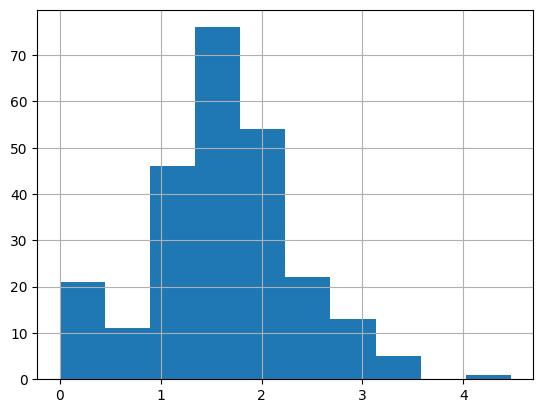

In [ ]:
import numpy as np
axs = np.log10(gmrepo_qc_runs['disease'].value_counts()).hist()

Let's take disease that appear more than 10 times. There isn't a long tail here, so this keeps 212/249 diseases

In [43]:
sum(gmrepo_qc_runs['disease'].value_counts() >= 10), len(gmrepo_qc_runs['disease'].value_counts())

(212, 249)

In [100]:
# Now, sample 10 random diseases with at least 10 runs each, and use those for downstream evaluation
disease_counts = gmrepo_qc_runs["disease"].value_counts()
valid_diseases = disease_counts[disease_counts >= 10].index

gmrepo_qc_runs_10disease = (
    gmrepo_qc_runs[gmrepo_qc_runs["disease"].isin(valid_diseases)]
    .groupby("disease", group_keys=True)
    .apply(lambda x: x.sample(n=10, replace=False, random_state=42))
    .reset_index(drop=False)
)

Ok, now the task is to get the abundance data.

In [101]:
gmrepo_qc_runs_10disease.head()

,disease,level_1,project_id,run_id,experiment_type,instrument_model,nr_reads_sequenced,host_age,sex,BMI,country,longitude,latitude,QCstatus
0,C535456,108558,PRJEB22984,ERR2442428,AMPLICON,Illumina MiSeq,205514.0,13.0,female,NaN,Germany,NaN,NaN,1.0
1,C535456,108582,PRJEB22984,ERR2442435,AMPLICON,Illumina MiSeq,147325.0,13.0,female,NaN,Germany,NaN,NaN,1.0
2,C535456,108567,PRJEB22984,ERR2442397,AMPLICON,Illumina MiSeq,252271.0,11.0,female,NaN,Germany,NaN,NaN,1.0
3,C535456,108559,PRJEB22984,ERR2442407,AMPLICON,Illumina MiSeq,208726.0,17.0,male,NaN,Germany,NaN,NaN,1.0
4,C535456,108584,PRJEB22984,ERR2442387,AMPLICON,Illumina MiSeq,156227.0,14.0,male,NaN,Germany,NaN,NaN,1.0


In [52]:
gmrepo_qc_runs_10disease.head()

,project_id,run_id,experiment_type,instrument_model,nr_reads_sequenced,host_age,sex,BMI,country,longitude,latitude,QCstatus
0,PRJEB22984,ERR2442428,AMPLICON,Illumina MiSeq,205514.0,13.0,female,NaN,Germany,NaN,NaN,1.0
1,PRJEB22984,ERR2442435,AMPLICON,Illumina MiSeq,147325.0,13.0,female,NaN,Germany,NaN,NaN,1.0
2,PRJEB22984,ERR2442397,AMPLICON,Illumina MiSeq,252271.0,11.0,female,NaN,Germany,NaN,NaN,1.0
3,PRJEB22984,ERR2442407,AMPLICON,Illumina MiSeq,208726.0,17.0,male,NaN,Germany,NaN,NaN,1.0
4,PRJEB22984,ERR2442387,AMPLICON,Illumina MiSeq,156227.0,14.0,male,NaN,Germany,NaN,NaN,1.0


In [68]:
len(gmrepo_qc_runs_10disease['run_id'].unique())

2120

In [73]:
# claude found an api I can call... not really sure where it found it, but it did...

import requests
import time
from tqdm.auto import tqdm
from pathlib import Path

Path("data/gmrepo/taxonomic_profiles").mkdir(parents=True, exist_ok=True)

for run_id in tqdm(gmrepo_qc_runs_10disease['run_id']):
    out_path = Path(f"data/gmrepo/taxonomic_profiles/{run_id}.json")
    if out_path.exists():
        continue
    response = requests.post(
        "https://gmrepo.humangut.info/api/getFullTaxonomicProfileByRunID/",
        json={"run_id": run_id}
    )
    # print(response.text)
    with open(out_path, "w") as f:
        f.write(response.text)
    time.sleep(0.5)
    # break

  0%|          | 0/2120 [00:00<?, ?it/s]

In [122]:
# get the diseases
import math


Path("data/gmrepo/diseases").mkdir(parents=True, exist_ok=True)

# note, we're getting the names for all the disease because there are only 37 more than in our subsampled case.
for mesh_id in tqdm(gmrepo_qc_runs['disease'].unique()):
    # out_path = Path(f"data/gmrepo/diseases/{mesh_id}.json")
    # if out_path.exists():
    #     continue
    # if "|" in mesh_id:
    if isinstance(mesh_id, float) and math.isnan(mesh_id):
        continue

    
    for mid in mesh_id.split("|"):
        if "|" in mesh_id:
            print(mesh_id)
        out_path = Path(f"data/gmrepo/diseases/{mid}.json")
        if out_path.exists():
            continue
        response = requests.get(
            f"https://id.nlm.nih.gov/mesh/lookup/details?descriptor={mid}",
            headers={"Accept": "application/json"}
        )
        with open(out_path, "w") as f:
            f.write(response.text)
            time.sleep(0.3)

  0%|          | 0/250 [00:00<?, ?it/s]

D015228|D010195
D015228|D010195


In [ ]:
import requests
response = requests.post(
    "https://gmrepo.humangut.info/api/getFullTaxonomicProfileByRunID/",
    json={"run_id": "ERR2442428"}
)



In [134]:
# load in the data curate an eval datsaset.

import json


out_dataset = []
for run_tup in tqdm(gmrepo_qc_runs_10disease.itertuples(), total=len(gmrepo_qc_runs_10disease)):
    run_id = run_tup.run_id
    out_path = Path(f"data/gmrepo/taxonomic_profiles/{run_id}.json")
    with open(out_path, "r") as f:
        taxonomic_profile = json.load(f)
    run_dict = run_tup._asdict()
    run_dict["taxonomic_profile_genus"] = taxonomic_profile.get("genus")
    run_dict["taxonomic_profile_species"] = taxonomic_profile.get("species")

    prompt_template = """
Given the following taxonomic profile of the abundance of certain bacteria in a human gut sample, predict what disease the human has or say \"Healthy\" if there is no disease.

Taxonomic Profile ({phylum} level):
{profile}
""".strip()
    genus_prompt = None
    species_prompt = None
    if run_dict["taxonomic_profile_genus"] is not None:
        tp_str = "\n".join([
            f'{bact["scientific_name"]}: {bact["relative_abundance"]:.3f}%'
            for bact in taxonomic_profile["genus"]
        ])
        genus_prompt = prompt_template.format(
            phylum="genus",
            profile=tp_str
        )
    if run_dict["taxonomic_profile_species"] is not None:
        tp_str = "\n".join([
            f'{bact["scientific_name"]}: {bact["relative_abundance"]:.3f}%'
            for bact in taxonomic_profile["species"]
        ])
        species_prompt = prompt_template.format(
            phylum="species",
            profile=tp_str
        )
    run_dict["prompt_genus"] = genus_prompt
    run_dict["prompt_species"] = species_prompt

    gold_label_set = []
    for mid in run_dict["disease"].split("|"):
        with open(Path(f"data/gmrepo/diseases/{mid}.json"), "r") as f:
            disease_info = json.load(f)
            gold_label_set.extend([t['label'] for t in disease_info['terms']])
    
    run_dict["gold_label_set"] = gold_label_set
    out_dataset.append(run_dict)
    # break

  0%|          | 0/2120 [00:00<?, ?it/s]

In [121]:
sum(["|" in l for l in gmrepo_qc_runs_10disease['disease'].to_list()])

10

In [139]:
import random
random.seed(42)
for i in range(5):
    idx = random.randint(0, len(out_dataset)-1)
    print("Question:")
    print(idx)
    print(out_dataset[idx]['prompt_genus'])

    print("Ground truth:")
    print(out_dataset[idx]['gold_label_set'])
    print("\n---\n")

Question:
456
Given the following taxonomic profile of the abundance of certain bacteria in a human gut sample, predict what disease the human has or say "Healthy" if there is no disease.

Taxonomic Profile (genus level):
Segatella: 86.688%
Lachnospira: 4.240%
Dialister: 1.399%
Sutterella: 1.186%
Roseburia: 1.060%
Alistipes: 0.708%
Bacteroides: 0.689%
Mediterraneibacter: 0.669%
Faecalibacterium: 0.597%
Ruminococcus: 0.418%
Clostridium: 0.294%
Gemmiger: 0.272%
Collinsella: 0.244%
Blautia: 0.192%
Coprococcus: 0.080%
Lacrimispora: 0.073%
Anaerostipes: 0.070%
Simiaoa: 0.059%
Dorea: 0.057%
Catenibacterium: 0.048%
Holdemanella: 0.044%
Bifidobacterium: 0.038%
Anaerobutyricum: 0.036%
Fusicatenibacter: 0.033%
Streptococcus: 0.020%
Waltera: 0.017%
Wujia: 0.015%
Romboutsia: 0.014%
Lactobacillus: 0.013%
Eubacterium: 0.010%
Faecalibacillus: 0.008%
Eggerthella: 0.008%
Faecalicatena: 0.007%
Agathobaculum: 0.007%
Turicibacter: 0.007%
Anaerotignum: 0.007%
Dysosmobacter: 0.004%
Escherichia: 0.004%
Flavo

In [ ]:
# upload to huggingface

with open("data/gmrepo/hf_dataset/gmrepo_eval.jsonl", "w") as f:
    for line in out_dataset:
        f.write(json.dumps(line) + "\n")

In [144]:
!uv pip install huggingface_hub

Resolved 22 packages in 2.17s                                        
Prepared 9 packages in 370ms                                             
Installed 20 packages in 2.47s15.0                          
 + annotated-doc==0.0.4
 + anyio==4.13.0
 + certifi==2026.5.20
 + click==8.4.0
 + filelock==3.29.0
 + fsspec==2026.4.0
 + h11==0.16.0
 + hf-xet==1.5.0
 + httpcore==1.0.9
 + httpx==0.28.1
 + huggingface-hub==1.15.0
 + idna==3.15
 + markdown-it-py==4.2.0
 + mdurl==0.1.2
 + pygments==2.20.0
 + pyyaml==6.0.3
 + rich==15.0.0
 + shellingham==1.5.4
 + typer==0.25.1
 + typing-extensions==4.15.0


In [ ]:
from huggingface_hub import login, upload_folder


login()


upload_folder(folder_path="data/gmrepo/hf_dataset/", repo_id="microbiome-fm/gmrepo_eval", repo_type="dataset")

In [ ]:
token = (Path.home() / ".hf_token_fs").open().read().strip()
upload_folder(
    folder_path="data/gmrepo/hf_dataset/",
    repo_id="microbiome-fm/gmrepo_eval",
    repo_type="dataset",
    token=token,
    # commit_message="Initial upload of GMRepo eval dataset", # change this
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/microbiome-fm/gmrepo_eval/commit/5f232b829d18e3795f9d8bf76ba5190fb1f1af7c', commit_message='Upload folder using huggingface_hub', commit_description='', oid='5f232b829d18e3795f9d8bf76ba5190fb1f1af7c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/microbiome-fm/gmrepo_eval', endpoint='https://huggingface.co', repo_type='dataset', repo_id='microbiome-fm/gmrepo_eval'), pr_revision=None, pr_num=None)

In [133]:
pd.DataFrame(out_dataset)['taxonomic_profile_species'].isna().sum()

np.int64(1608)

In [ ]:
pd.DataFrame(out_dataset)['species'].isna().sum()

In [108]:
print("\n".join([
    f'{bact["scientific_name"]}: {bact["relative_abundance"]:.3f}%'
    for bact in taxonomic_profile.get("genus")
]))

Bacteroides: 18.184%
Agathobacter: 12.041%
Faecalibacterium: 11.811%
Muribaculaceae: 7.239%
Eubacterium: 6.034%
Alistipes: 2.974%
Parasutterella: 2.937%
Asteroleplasma: 1.806%
Dorea: 1.600%
Butyricicoccus: 1.383%
Ruminococcus: 1.338%
Monoglobus: 1.107%
Lachnospira: 1.066%
Parabacteroides: 0.837%
Barnesiella: 0.705%
Fusicatenibacter: 0.424%
Subdoligranulum: 0.348%
Blautia: 0.338%
Collinsella: 0.295%
Holdemanella: 0.228%
Odoribacter: 0.192%
Anaerostipes: 0.191%
Coprococcus: 0.185%
Mediterraneibacter: 0.163%
Colidextribacter: 0.120%
Candidatus Izemoplasmatales: 0.113%
Brachyspira: 0.082%
Lachnoclostridium: 0.068%
Negativibacillus: 0.054%
Oscillospira: 0.052%
Haemophilus: 0.041%
Phascolarctobacterium: 0.033%
Roseburia: 0.032%
Bilophila: 0.029%
Clostridium: 0.029%
Coprobacter: 0.028%
Veillonella: 0.028%
Turicibacter: 0.026%
Oscillibacter: 0.021%
Marvinbryantia: 0.021%
Anaerofilum: 0.020%
Romboutsia: 0.015%
Streptococcus: 0.013%
Campylobacter: 0.003%
Unknown: 25.747%


In [89]:
run_tup._asdict()

{'Index': 0,
 'project_id': 'PRJEB22984',
 'run_id': 'ERR2442428',
 'experiment_type': 'AMPLICON',
 'instrument_model': 'Illumina MiSeq',
 'nr_reads_sequenced': 205514.0,
 'host_age': 13.0,
 'sex': 'female',
 'BMI': nan,
 'country': 'Germany',
 'longitude': nan,
 'latitude': nan,
 'QCstatus': 1.0}

In [83]:
taxonomic_profile["genus"]

[{'loaded_uid': 73686,
  'ncbi_taxon_id': 816,
  'taxon_rank_level': 'genus',
  'relative_abundance': 18.1835948726792,
  'scientific_name': 'Bacteroides'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 1766253,
  'taxon_rank_level': 'genus',
  'relative_abundance': 12.041156521239294,
  'scientific_name': 'Agathobacter'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 216851,
  'taxon_rank_level': 'genus',
  'relative_abundance': 11.811231821578431,
  'scientific_name': 'Faecalibacterium'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 2005473,
  'taxon_rank_level': 'genus',
  'relative_abundance': 7.23917916882221,
  'scientific_name': 'Muribaculaceae'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 1730,
  'taxon_rank_level': 'genus',
  'relative_abundance': 6.034373742599299,
  'scientific_name': 'Eubacterium'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 239759,
  'taxon_rank_level': 'genus',
  'relative_abundance': 2.974075990113238,
  'scientific_name': 'Alistipes'},
 {'loaded_uid': 73686,
  'ncbi

In [60]:
print(response.text)

{"run": [{"project_id": "PRJEB22984", "original_sample_description": "Analysis of the fecal and oral microbiota in chronic recurrent multifocal osteomyelitis", "run_id": "ERR2442428", "experiment_type": "AMPLICON", "instrument_model": "Illumina MiSeq", "nr_reads_sequenced": 205514, "host_age": 13.0, "sex": "female", "BMI": null, "country": "Germany", "longitude": null, "latitude": null, "loaded_uid": 73686, "QCStatus": 1, "QCMessage": "Forward left trim: 4;Forward right trim: 252;Reverse left trim: 4;Reverse right trim: 188", "Original_Project_description": "Chronic recurrent multifocal osteomyelitis (CRMO) is a rare autoinflammatory bone disease for which a lack of bacterial involvement is a key diagnostic feature to distinguish it from other symptomatically related diseases. However, the growing evidence suggesting an involvement of the host-associated microbiota in rheumatic disorders together with the now wide accessibility of modern metagenomic methods warrant a closer examination

In [62]:
pd.DataFrame(response.json()["run"])

,project_id,original_sample_description,run_id,experiment_type,instrument_model,nr_reads_sequenced,host_age,sex,BMI,country,longitude,latitude,loaded_uid,QCStatus,QCMessage,Original_Project_description
0,PRJEB22984,Analysis of the fecal and oral microbiota in c...,ERR2442428,AMPLICON,Illumina MiSeq,205514,13.0,female,None,Germany,None,None,73686,1,Forward left trim: 4;Forward right trim: 252;R...,Chronic recurrent multifocal osteomyelitis (CR...


In [63]:
response.json().keys()

dict_keys(['run', 'phenotypes_exist', 'phenotypes', 'genus'])

In [66]:
response.json()['genus']

[{'loaded_uid': 73686,
  'ncbi_taxon_id': 816,
  'taxon_rank_level': 'genus',
  'relative_abundance': 18.1835948726792,
  'scientific_name': 'Bacteroides'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 1766253,
  'taxon_rank_level': 'genus',
  'relative_abundance': 12.041156521239294,
  'scientific_name': 'Agathobacter'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 216851,
  'taxon_rank_level': 'genus',
  'relative_abundance': 11.811231821578431,
  'scientific_name': 'Faecalibacterium'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 2005473,
  'taxon_rank_level': 'genus',
  'relative_abundance': 7.23917916882221,
  'scientific_name': 'Muribaculaceae'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 1730,
  'taxon_rank_level': 'genus',
  'relative_abundance': 6.034373742599299,
  'scientific_name': 'Eubacterium'},
 {'loaded_uid': 73686,
  'ncbi_taxon_id': 239759,
  'taxon_rank_level': 'genus',
  'relative_abundance': 2.974075990113238,
  'scientific_name': 'Alistipes'},
 {'loaded_uid': 73686,
  'ncbi